# CAGED Curitiba — análise exploratória

Alvo: `saldomovimentacao` (−1 desligamento, 1 admissão).

## 1. Imports e carga

In [29]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.ml_pipeline import (
    ALLOWED_MONTHS,
    TARGET_COLUMN,
    TEST_FILE,
    TRAIN_FILE,
    load_csv,
    preprocess_dataframe,
    project_root,
)

sns.set_theme(style="whitegrid")
root = project_root()
train_df = load_csv(root / TRAIN_FILE)
test_df = load_csv(root / TEST_FILE)
print(train_df.shape, "treino |", test_df.shape, "teste")
print("só no treino:", sorted(set(train_df.columns) - set(test_df.columns)))
print("só no teste:", sorted(set(test_df.columns) - set(train_df.columns)))
train_df.head(3)

(742427, 26) treino | (140020, 25) teste
só no treino: ['saldomovimentacao']
só no teste: []


,competenciamov,regiao,uf,municipio,secao,subclasse,saldomovimentacao,cbo2002ocupacao,categoria,graudeinstrucao,...,tipodedeficiencia,indtrabintermitente,indtrabparcial,salario,tamestabjan,indicadoraprendiz,origemdainformacao,competenciadec,unidadesalariocodigo,valorsalariofixo
0,202301,4,41,410690,S,9420100,1,411010,101,9,...,0,0,0,2935.24,7,0,1,202401,1,5.0
1,202301,4,41,410690,Q,8800600,1,515305,101,9,...,0,0,0,900.00,4,0,1,202401,1,5.0
2,202301,4,41,410690,G,4520005,1,519935,101,7,...,0,0,0,1540.00,3,0,1,202401,1,5.0


## 2. Filtro (meses do trabalho) e pré-processamento

In [11]:
filtered_train = train_df[train_df["competenciadec"].isin(ALLOWED_MONTHS)].copy()
transformed_train = preprocess_dataframe(train_df, include_target=True)
transformed_test = preprocess_dataframe(test_df, include_target=False)
filtered_transformed_train = transformed_train[
    transformed_train["competenciadec"].isin(ALLOWED_MONTHS)
].copy()
print(len(filtered_train), "linhas após filtro | meses:", sorted(ALLOWED_MONTHS))

741271 linhas após filtro | meses: [202401, 202411, 202412, 202501, 202511, 202512]


## 3. Números: alvo, tempo, categorias, faltantes

In [12]:
# Alvo
print("Alvo (%):")
print(
    filtered_train[TARGET_COLUMN]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)
print("\nPor competência:")
print(filtered_train["competenciadec"].value_counts().sort_index())
print("\nTop 10 seções:")
print(filtered_train["secao"].value_counts().head(10))
print("\nDescribe idade / salario / valorsalariofixo:")
print(filtered_train[["idade", "salario", "valorsalariofixo"]].describe().round(2))
missing_ratio = (
    filtered_train.isna().mean().sort_values(ascending=False).mul(100).round(4)
)
print("\n% missing (top 10 colunas):")
print(missing_ratio.head(10))
print("\n# categorias distintas:")
for col in ["secao", "subclasse", "cbo2002ocupacao", "categoria", "graudeinstrucao"]:
    if col in filtered_train.columns:
        print(f"  {col}: {filtered_train[col].nunique(dropna=False)}")
print("\nvalorsalariofixo (mais frequentes):")
print(filtered_train["valorsalariofixo"].value_counts(dropna=False).head(10))
for c in ("cbo_grupo", "subclasse_grupo", "secao_subclasse"):
    if c in filtered_transformed_train.columns:
        print(f"  {c}: {filtered_transformed_train[c].nunique(dropna=False)} únicos")

Alvo (%):
saldomovimentacao
-1    51.02
 1    48.98
Name: proportion, dtype: float64

Por competência:
competenciadec
202401    128485
202411    123091
202412    110627
202501    141911
202511    123462
202512    113695
Name: count, dtype: int64

Top 10 seções:
secao
N    224117
G    160726
C     75677
F     65225
I     53489
H     40250
Q     24667
M     23620
P     19789
J     14687
Name: count, dtype: int64

Describe idade / salario / valorsalariofixo:
           idade     salario  valorsalariofixo
count  741268.00   741271.00         741271.00
mean       33.10     2318.93              4.65
std        11.51     5755.78              2.82
min        14.00        0.00              1.00
25%        24.00     1685.20              5.00
50%        31.00     1928.00              5.00
75%        41.00     2300.00              5.00
max        97.00  1229200.00             99.00

% missing (top 10 colunas):
idade                   0.0004
competenciamov          0.0000
tipoempregador          0.

## 4. Gráficos (marginais)

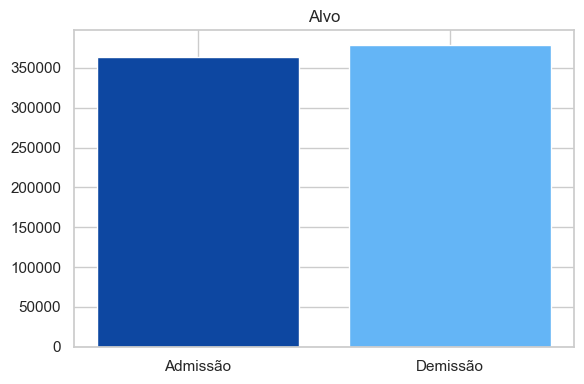

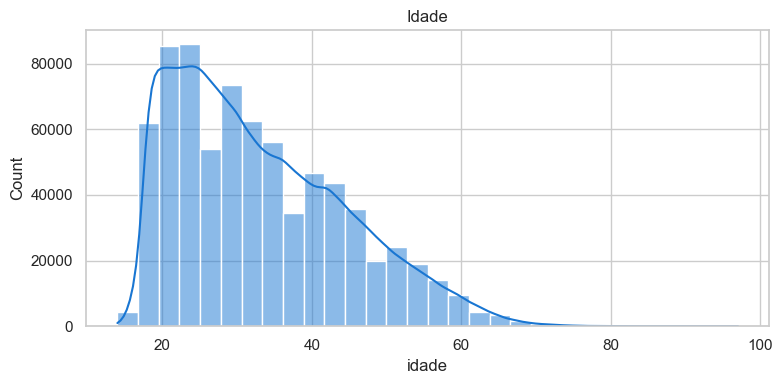

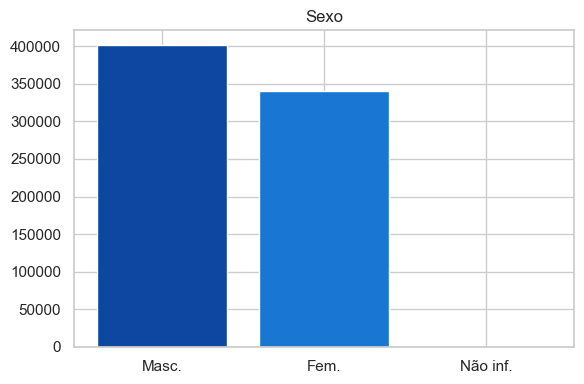

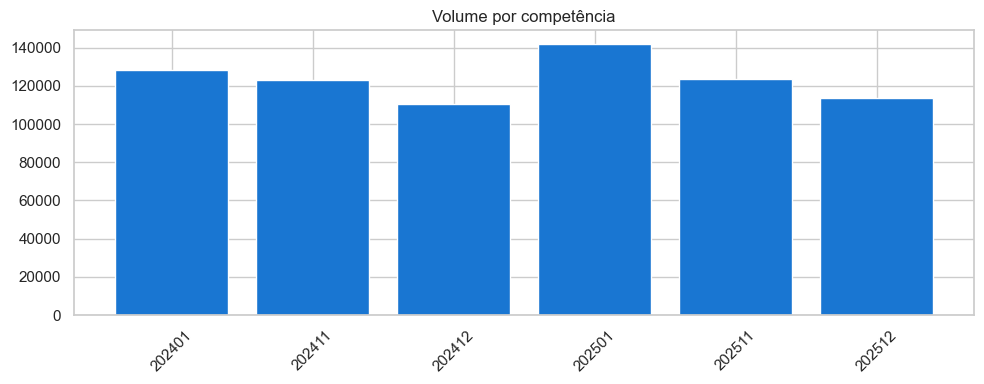

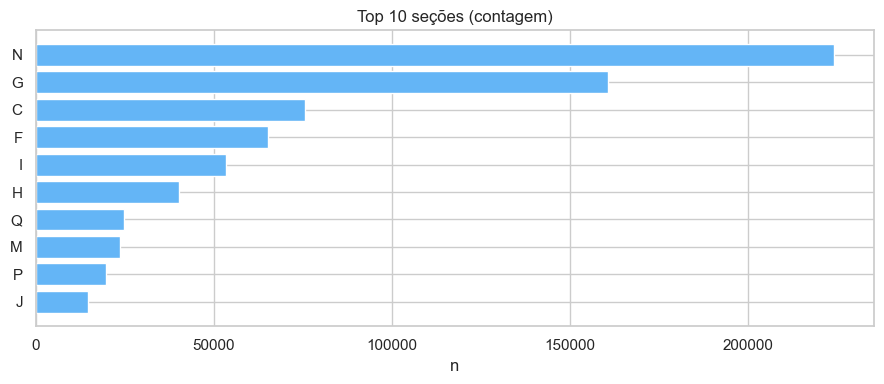

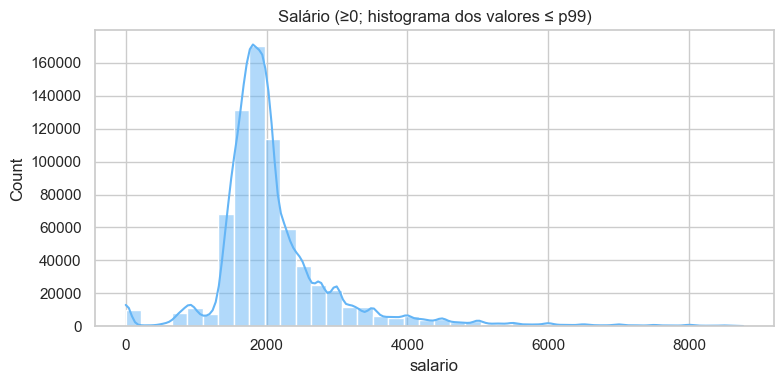

In [ ]:
target_map = {1: "Admissão", -1: "Demissão"}
filtered_train["target_label"] = filtered_train[TARGET_COLUMN].map(target_map)

# Paleta: tons de azul (consistente em todos os gráficos)
B = {
    "d": "#0d47a1",
    "m": "#1976d2",
    "l": "#64b5f6",
    "p": "#90caf9",
}
BL2 = [B["d"], B["l"]]
BL3 = [B["d"], B["m"], B["l"]]

# Barras com matplotlib (evita avisos do seaborn 0.13+ com palette/hue)
order_lbl = ["Admissão", "Demissão"]
cnt_alvo = filtered_train["target_label"].value_counts().reindex(order_lbl).fillna(0).astype(int)
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(order_lbl, cnt_alvo.values, color=BL2)
ax.set_title("Alvo")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(filtered_train["idade"].dropna(), bins=30, kde=True, ax=ax, color=B["m"])
ax.set_title("Idade")
plt.tight_layout()
plt.show()

sexo_map = {1: "Masc.", 3: "Fem.", 9: "Não inf."}
sx = filtered_train[filtered_train["sexo"].isin(sexo_map)].copy()
sx["sexo_l"] = sx["sexo"].map(sexo_map)
ord_sx = ["Masc.", "Fem.", "Não inf."]
cnt_sx = sx["sexo_l"].value_counts().reindex(ord_sx).fillna(0).astype(int)
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(ord_sx, cnt_sx.values, color=BL3)
ax.set_title("Sexo")
plt.tight_layout()
plt.show()

mo = sorted(filtered_train["competenciadec"].unique())
cnt_m = filtered_train["competenciadec"].value_counts().reindex(mo).fillna(0).astype(int)
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(len(mo)), cnt_m.values, color=B["m"])
ax.set_xticks(range(len(mo)))
ax.set_xticklabels(mo, rotation=45)
ax.set_title("Volume por competência")
plt.tight_layout()
plt.show()

top_sec = filtered_train["secao"].value_counts().head(10)
fig, ax = plt.subplots(figsize=(9, 4))
y = range(len(top_sec))
ax.barh(y, top_sec.values, color=B["l"])
ax.set_yticks(y)
ax.set_yticklabels(top_sec.index)
ax.invert_yaxis()
ax.set_title("Top 10 seções (contagem)")
ax.set_xlabel("n")
plt.tight_layout()
plt.show()

s_sal = filtered_train["salario"].clip(lower=0)
sal_p99 = s_sal.quantile(0.99)
s_sal_ate_p99 = s_sal[s_sal <= sal_p99]
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(s_sal_ate_p99, bins=40, kde=True, ax=ax, color=B["l"])
ax.set_title("Salário (≥0; histograma dos valores ≤ p99)")
plt.tight_layout()
plt.show()

## 5. Correlação (Pearson, variáveis numéricas)

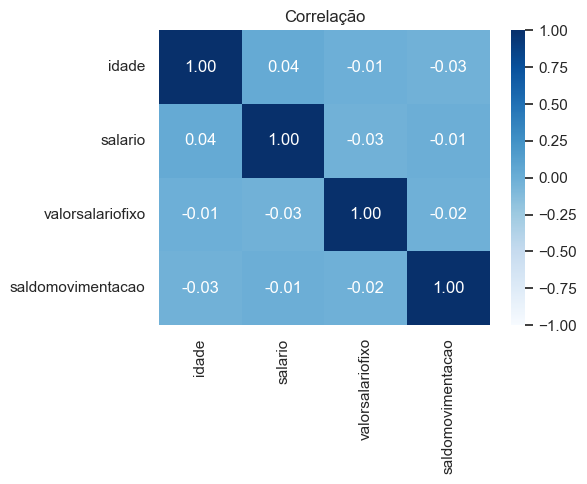

In [22]:
cols = ["idade", "salario", "valorsalariofixo", TARGET_COLUMN]
plt.figure(figsize=(6, 5))
sns.heatmap(
    filtered_train[cols].corr(),
    annot=True,
    cmap="Blues",
    vmin=-1,
    vmax=1,
    fmt=".2f",
)
plt.title("Correlação")
plt.tight_layout()
plt.show()

## 6. Alvo × competência e alvo × salário

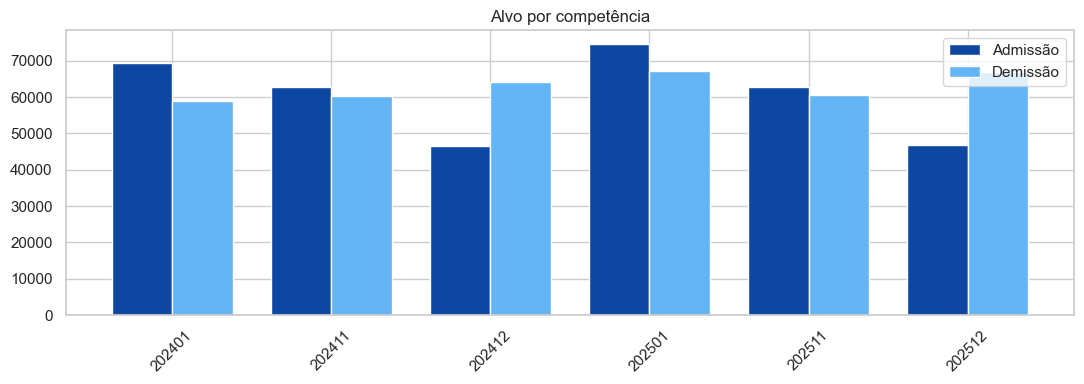

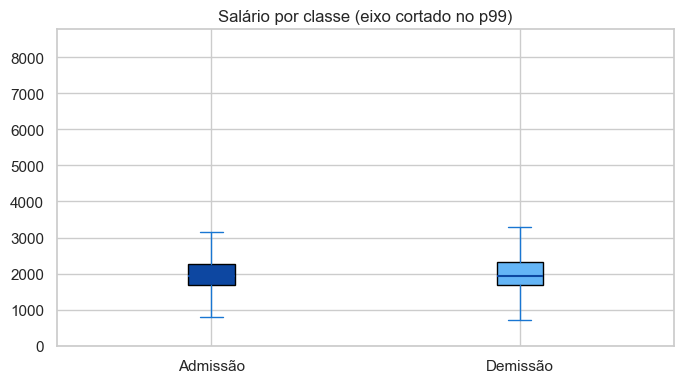

In [27]:
mo = sorted(filtered_train["competenciadec"].unique())
ct = pd.crosstab(filtered_train["competenciadec"], filtered_train["target_label"])
ct = ct.reindex(mo, fill_value=0)
labels = ["Admissão", "Demissão"]
for lab in labels:
    if lab not in ct.columns:
        ct[lab] = 0
ct = ct[labels]

B = {"d": "#0d47a1", "m": "#1976d2", "l": "#64b5f6"}
BL2 = [B["d"], B["l"]]

x = range(len(mo))
w = 0.38
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar([i - w / 2 for i in x], ct["Admissão"], width=w, label="Admissão", color=BL2[0])
ax.bar([i + w / 2 for i in x], ct["Demissão"], width=w, label="Demissão", color=BL2[1])
ax.set_xticks(list(x))
ax.set_xticklabels(mo, rotation=45)
ax.set_title("Alvo por competência")
ax.set_xlabel("")
ax.legend(title="")
plt.tight_layout()
plt.show()

lim = filtered_train["salario"].clip(lower=0).quantile(0.99)
sub = filtered_train[["target_label", "salario"]].copy()
sub["salario"] = sub["salario"].clip(lower=0)
fig, ax = plt.subplots(figsize=(7, 4))
bp = ax.boxplot(
    [
        sub.loc[sub["target_label"] == "Admissão", "salario"],
        sub.loc[sub["target_label"] == "Demissão", "salario"],
    ],
    tick_labels=["Admissão", "Demissão"],
    patch_artist=True,
    showfliers=False,
    medianprops={"color": B["d"], "linewidth": 1.5},
    whiskerprops={"color": B["m"]},
    capprops={"color": B["m"]},
)
for patch, c in zip(bp["boxes"], BL2):
    patch.set_facecolor(c)
ax.set_ylim(0, lim)
ax.set_title("Salário por classe (eixo cortado no p99)")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

## 6.1 Alvo × grau de instrução

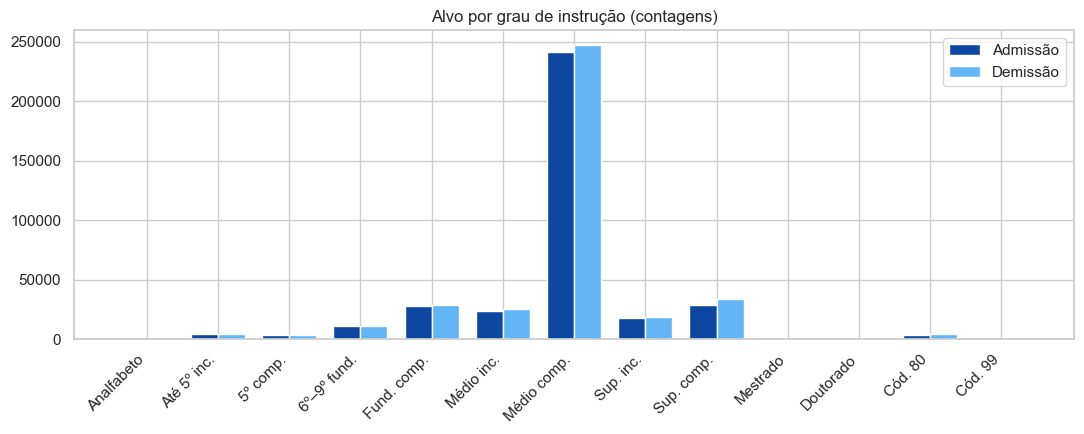

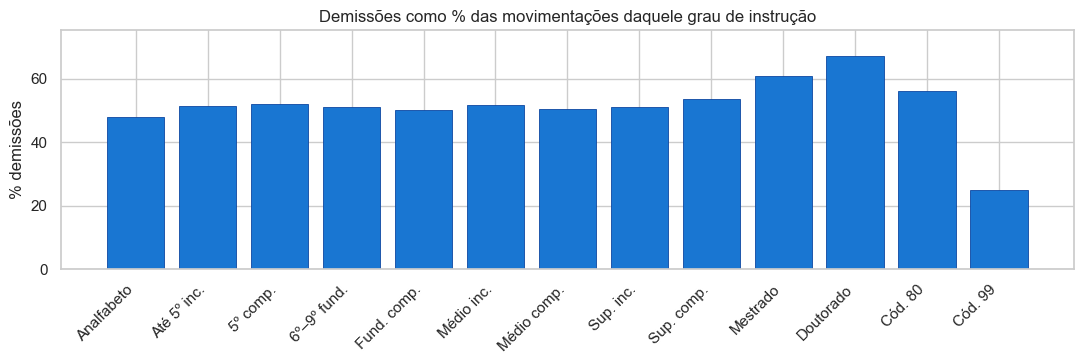

In [ ]:
labels = ["Admissão", "Demissão"]
GRAU_CAGED = {
    1: "Analfabeto",
    2: "Até 5º inc.",
    3: "5º comp.",
    4: "6º–9º fund.",
    5: "Fund. comp.",
    6: "Médio inc.",
    7: "Médio comp.",
    8: "Sup. inc.",
    9: "Sup. comp.",
    10: "Mestrado",
    11: "Doutorado",
}

subg = filtered_train[["graudeinstrucao", "target_label"]].dropna(subset=["graudeinstrucao"])
ct_g = pd.crosstab(subg["graudeinstrucao"], subg["target_label"])
for lab in labels:
    if lab not in ct_g.columns:
        ct_g[lab] = 0
ct_g = ct_g[labels]
ordem = sorted(ct_g.index.astype(int))
ct_g = ct_g.reindex(ordem, fill_value=0)

B = {"d": "#0d47a1", "m": "#1976d2", "l": "#64b5f6"}
BL2 = [B["d"], B["l"]]
tick_lbls = [GRAU_CAGED.get(int(c), f"Cód. {int(c)}") for c in ordem]

x = range(len(ordem))
w = 0.38
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar([i - w / 2 for i in x], ct_g["Admissão"], width=w, label="Admissão", color=BL2[0])
ax.bar([i + w / 2 for i in x], ct_g["Demissão"], width=w, label="Demissão", color=BL2[1])
ax.set_xticks(list(x))
ax.set_xticklabels(tick_lbls, rotation=45, ha="right")
ax.set_title("Alvo por grau de instrução (contagens)")
ax.set_xlabel("")
ax.legend(title="")
plt.tight_layout()
plt.show()

tot = ct_g["Admissão"] + ct_g["Demissão"]
pct_series = (ct_g["Demissão"] / tot * 100).where(tot > 0, 0)
fig, ax = plt.subplots(figsize=(11, 3.8))
ax.bar(list(x), pct_series, color=B["m"], edgecolor=B["d"], linewidth=0.6)
ax.set_xticks(list(x))
ax.set_xticklabels(tick_lbls, rotation=45, ha="right")
ax.set_ylabel("% demissões")
ax.set_title("Demissões como % das movimentações daquele grau de instrução")
ymax = float(pct_series.max()) if len(pct_series) else 0
ax.set_ylim(0, min(100.0, ymax * 1.12 + 1e-9) if ymax > 0 else 1)
plt.tight_layout()
plt.show()

## 7. Síntese

In [24]:
n = len(filtered_train)
vc = filtered_train[TARGET_COLUMN].value_counts(normalize=True).sort_index()
miss_max = missing_ratio.iloc[0]
miss_col = missing_ratio.index[0]
print(f"Registros (filtro): {n:,}")
print(f"Classes: " + " | ".join(f"{int(k)} → {vc[k]*100:.2f}%" for k in vc.index))
print(f"Maior % faltante: {miss_max:.3f}% ({miss_col})")

Registros (filtro): 741,271
Classes: -1 → 51.02% | 1 → 48.98%
Maior % faltante: 0.000% (idade)
